# Proyek Klasifikasi Gambar: Plants Classification
- **Nama:** M. Sobahus Sururin Ni'am
- **Email:** sobahusn27@gmail.com
- **ID Dicoding:** https://www.dicoding.com/users/sobahusn/

## Import Semua Packages/Library yang Digunakan

In [4]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense,
    Dropout, BatchNormalization, Rescaling, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import ( EarlyStopping, ReduceLROnPlateau, ModelCheckpoint )

I0000 00:00:1777422465.303808  755545 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777422466.275033  755545 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777422472.264432  755545 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Data Preparation

### Data Loading

In [ ]:
# # Install Kaggle
# !pip install -q kaggle

# # Upload kaggle.json
# from google.colab import files
# files.upload()

# # Konfigurasi Kaggle API
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # Download Dataset
# !kaggle datasets download -d marquis03/plants-classification

# # Extract Dataset
# !unzip -q plants-classification.zip -d dataset

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/marquis03/plants-classification
License(s): apache-2.0
plants-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


### Data Preprocessing

#### Split Dataset

In [5]:
base_path = '../Datasets/Plants-Classification/dataset'
folders_to_combine = ['val', 'test']
target_folder = 'combined_val_test_ds'

# Langkah 1: Penggabungan Fisik (Semua masuk ke 'train')
for folder in folders_to_combine:
    source_dir = os.path.join(base_path, folder)
    if os.path.exists(source_dir):
        for class_name in os.listdir(source_dir):
            class_path = os.path.join(source_dir, class_name)
            if os.path.isdir(class_path):
                # Folder tujuan di dalam 'train'
                dest_dir = os.path.join(base_path, target_folder, class_name)
                os.makedirs(dest_dir, exist_ok=True)

                for file_name in os.listdir(class_path):
                    source_file = os.path.join(class_path, file_name)
                    # Pindahkan file
                    shutil.move(source_file, os.path.join(dest_dir, file_name))
    else:
        print(f"Warning: Folder '{source_dir}' tidak ditemukan.")

In [6]:
all_data_dir = os.path.join(base_path, 'train')
img_size = (224, 224)
batch_size = 32

# Ambil 80% untuk Training
train_ds = tf.keras.utils.image_dataset_from_directory(
    all_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Ambil 20% sisanya untuk digabung antara Validation & Test
temp_ds = tf.keras.utils.image_dataset_from_directory(
    all_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Membagi sisa 20% menjadi 10% Val dan 10% Test
total_batches = tf.data.experimental.cardinality(temp_ds)
val_ds = temp_ds.take(total_batches // 2)
test_ds = temp_ds.skip(total_batches // 2)

print(f"\nTrain batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

Found 21000 files belonging to 30 classes.
Using 16800 files for training.


E0000 00:00:1777422491.894647  755545 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 21000 files belonging to 30 classes.
Using 4200 files for validation.

Train batches: 525
Val batches: 66
Test batches: 66


## Exploratory Data Analysis

Jumlah Class : 30
['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']


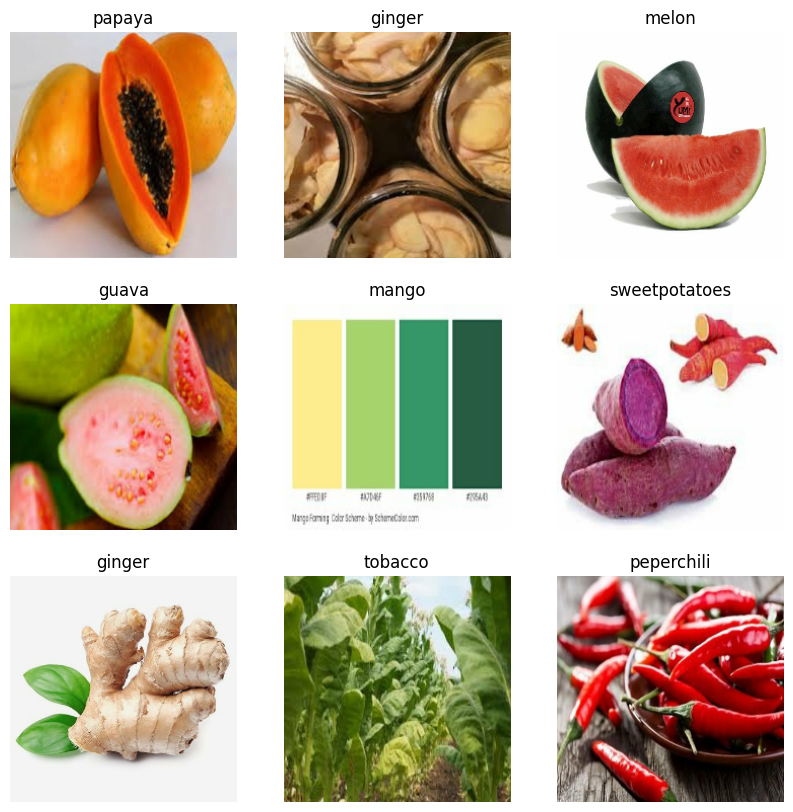

In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Jumlah Class :", num_classes)
print(class_names)

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

### Data Augmentation

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

## Modelling

In [9]:
tf.keras.backend.clear_session()

# Initialize MobileNetV2 as the base model
# Input shape adjusted to (224, 224, 3) to match the dataset's img_size
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model layers

model = Sequential([
    Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/home/niam/Documents/Bootcamp/Dicoding-PIJAK/Belajar Fundamental Deep Learning/Submissions/Proyek Klasifikasi Gambar/deployment/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compile Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,822 (9.25 MB)

 Trainable params: 167,838 (655.62 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


## Callback Training

In [11]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_model.h5",
        save_best_only=True
    )
]

## Training Model

In [ ]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks
)

## Evaluasi dan Visualisasi

In [ ]:
# Visualisasi Accuracy dan Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])

plt.show()

## Confusion Matrix

In [ ]:
# Generate predictions for test_ds
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_raw = model.predict(test_ds)
y_pred = np.argmax(y_pred_raw, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", annot=True, fmt='g') # Added annot and fmt for better visualization

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Evaluasi Model
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

## Classification Report


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

## Konversi Model

### Saved Model

In [ ]:
model.export("saved_model")

### Konversi ke TensorFlow Lite (TFLite)

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
  f.write(tflite_model)

### Konversi ke TensorFlow JS (TFJS)

In [ ]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  saved_model \
  tfjs_model

## Inference (Optional)